<a href="https://colab.research.google.com/github/GinnaGomez09/proyecto_aplicado_javeriana/blob/main/notebooks/03_tokenizacion_lematizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# ============================================================
# 1. Clonar repositorio y preparar entorno
# ============================================================

!git clone https://github.com/GinnaGomez09/proyecto_aplicado_javeriana.git
%cd proyecto_aplicado_javeriana

Cloning into 'proyecto_aplicado_javeriana'...
remote: Enumerating objects: 293, done.
remote: Counting objects: 100% (151/151), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 293 (delta 101), reused 18 (delta 18), pack-reused 142 (from 1)
Receiving objects: 100% (293/293), 3.65 MiB | 5.29 MiB/s, done.
Resolving deltas: 100% (155/155), done.
/content/proyecto_aplicado_javeriana/proyecto_aplicado_javeriana


In [12]:
# ============================================================
# 2. Importar librerías
# ============================================================

import pandas as pd
import numpy as np
import os
import re
import unicodedata

In [13]:
# ============================================================
# 3. Cargar dataset original
# ============================================================

recetas_path = "data/raw/recetas/recetas_ingredientes.csv"

recetas = pd.read_csv(recetas_path)

print("Dimensiones:", recetas.shape)

recetas.head()

Dimensiones: (31587, 16)


,receta_uuid,receta_titulo,receta_url,ingrediente_id,ingrediente_linea,cantidad_original,cantidad_conv,cantidad_min,cantidad_max,unidad,ingrediente_nombre,tcac_alimento_codigo,tcac_alimento_nombre,match_method,match_score,cantidad_gramos_est
0,86af61e4-e16a-11ed-9591-a96d6180cd25,Arepas de Queso,https://www.mycolombianrecipes.com/es/arepas-d...,1,1 taza de harina de arepa blanca o amarilla,1,1.000000,NaN,NaN,taza,harina de arepa blanca o amarilla,NaN,NaN,NaN,NaN,NaN
1,86af61e4-e16a-11ed-9591-a96d6180cd25,Arepas de Queso,https://www.mycolombianrecipes.com/es/arepas-d...,2,1 taza de agua tibia,1,1.000000,NaN,NaN,taza,agua tibia,NaN,NaN,NaN,NaN,NaN
2,86af61e4-e16a-11ed-9591-a96d6180cd25,Arepas de Queso,https://www.mycolombianrecipes.com/es/arepas-d...,3,⅓ taza de queso mozzarella o queso blanco rallado,⅓,0.333333,NaN,NaN,taza,queso mozzarella o queso blanco rallado,NaN,NaN,NaN,NaN,NaN
3,86af61e4-e16a-11ed-9591-a96d6180cd25,Arepas de Queso,https://www.mycolombianrecipes.com/es/arepas-d...,4,2 cucharadas de mantequilla,2,2.000000,NaN,NaN,cucharadas,mantequilla,NaN,NaN,NaN,NaN,NaN
4,86af61e4-e16a-11ed-9591-a96d6180cd25,Arepas de Queso,https://www.mycolombianrecipes.com/es/arepas-d...,5,Sal,NaN,NaN,NaN,NaN,NaN,Sal,NaN,NaN,NaN,NaN,NaN


In [14]:
# ============================================================
# 4. Definición de columnas clave
# ============================================================

col_linea = "ingrediente_linea"
col_ingrediente = "ingrediente_nombre"
col_unidad = "unidad"

print("Columnas utilizadas:")
print(col_linea)
print(col_ingrediente)
print(col_unidad)

Columnas utilizadas:
ingrediente_linea
ingrediente_nombre
unidad


In [15]:
# ============================================================
# 5. Funciones de limpieza de texto
# ============================================================

def quitar_tildes(texto):
    if pd.isna(texto):
        return np.nan

    texto = str(texto)

    texto = unicodedata.normalize("NFKD", texto)

    texto = "".join(
        [c for c in texto if not unicodedata.combining(c)]
    )

    return texto


def limpiar_texto(texto):
    if pd.isna(texto):
        return np.nan

    texto = str(texto)

    # minúsculas
    texto = texto.lower()

    # eliminar tildes
    texto = quitar_tildes(texto)

    # eliminar caracteres especiales
    texto = re.sub(r"[^a-z0-9\s\/\.,]", " ", texto)

    # normalizar espacios
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

In [16]:
# ============================================================
# 6. Aplicar limpieza antes del NLP
# ============================================================

recetas["ingrediente_linea_limpia"] = recetas[col_linea].apply(
    limpiar_texto
)

recetas["ingrediente_nombre_limpio"] = recetas[col_ingrediente].apply(
    limpiar_texto
)

print("Limpieza aplicada correctamente")

recetas[
    [
        col_linea,
        "ingrediente_linea_limpia",
        col_ingrediente,
        "ingrediente_nombre_limpio"
    ]
].head()

Limpieza aplicada correctamente


,ingrediente_linea,ingrediente_linea_limpia,ingrediente_nombre,ingrediente_nombre_limpio
0,1 taza de harina de arepa blanca o amarilla,1 taza de harina de arepa blanca o amarilla,harina de arepa blanca o amarilla,harina de arepa blanca o amarilla
1,1 taza de agua tibia,1 taza de agua tibia,agua tibia,agua tibia
2,⅓ taza de queso mozzarella o queso blanco rallado,1 3 taza de queso mozzarella o queso blanco ra...,queso mozzarella o queso blanco rallado,queso mozzarella o queso blanco rallado
3,2 cucharadas de mantequilla,2 cucharadas de mantequilla,mantequilla,mantequilla
4,Sal,sal,Sal,sal


In [17]:
# ============================================================
# 7. Definición de columnas para NLP
# ============================================================

col_linea_limpia = "ingrediente_linea_limpia"
col_ingrediente_limpio = "ingrediente_nombre_limpio"

print("Columnas NLP:")
print(col_linea_limpia)
print(col_ingrediente_limpio)

Columnas NLP:
ingrediente_linea_limpia
ingrediente_nombre_limpio


In [18]:
# ============================================================
# 8. Instalación y carga de spaCy
# ============================================================

!pip install spacy -q
!python -m spacy download es_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 71.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [19]:
import spacy

nlp = spacy.load("es_core_news_sm")

print("Modelo spaCy cargado correctamente")

Modelo spaCy cargado correctamente


In [20]:
# ============================================================
# 9. Prueba inicial de tokenización y lematización
# ============================================================

ejemplo = recetas[col_linea_limpia].dropna().iloc[0]

doc = nlp(ejemplo)

print("Texto original limpio:")
print(ejemplo)

print("\nTokens:")
print([token.text for token in doc])

print("\nLemas:")
print([token.lemma_ for token in doc])

print("\nPOS tags:")
print([(token.text, token.pos_) for token in doc])

Texto original limpio:
1 taza de harina de arepa blanca o amarilla

Tokens:
['1', 'taza', 'de', 'harina', 'de', 'arepa', 'blanca', 'o', 'amarilla']

Lemas:
['1', 'taza', 'de', 'harina', 'de', 'arepa', 'blanco', 'o', 'amarillo']

POS tags:
[('1', 'NUM'), ('taza', 'NOUN'), ('de', 'ADP'), ('harina', 'NOUN'), ('de', 'ADP'), ('arepa', 'PROPN'), ('blanca', 'ADJ'), ('o', 'CCONJ'), ('amarilla', 'ADJ')]


In [21]:
# ============================================================
# 10. Funciones de tokenización y lematización
# ============================================================

def obtener_tokens(texto):
    if pd.isna(texto):
        return []

    doc = nlp(str(texto))

    return [
        token.text
        for token in doc
        if not token.is_space
    ]


def obtener_lemas(texto):
    if pd.isna(texto):
        return []

    doc = nlp(str(texto))

    return [
        token.lemma_
        for token in doc
        if not token.is_space and not token.is_punct
    ]


def obtener_pos(texto):
    if pd.isna(texto):
        return []

    doc = nlp(str(texto))

    return [
        (token.text, token.pos_)
        for token in doc
        if not token.is_space
    ]

In [22]:
# ============================================================
# 11. Aplicar tokenización y lematización
# ============================================================

recetas_nlp = recetas.copy()

recetas_nlp["tokens_linea"] = recetas_nlp[
    col_linea_limpia
].apply(obtener_tokens)

recetas_nlp["lemas_linea"] = recetas_nlp[
    col_linea_limpia
].apply(obtener_lemas)

recetas_nlp["pos_linea"] = recetas_nlp[
    col_linea_limpia
].apply(obtener_pos)

recetas_nlp[
    [
        col_linea_limpia,
        "tokens_linea",
        "lemas_linea",
        "pos_linea"
    ]
].head(20)

,ingrediente_linea_limpia,tokens_linea,lemas_linea,pos_linea
0,1 taza de harina de arepa blanca o amarilla,"[1, taza, de, harina, de, arepa, blanca, o, am...","[1, taza, de, harina, de, arepa, blanco, o, am...","[(1, NUM), (taza, NOUN), (de, ADP), (harina, N..."
1,1 taza de agua tibia,"[1, taza, de, agua, tibia]","[1, taza, de, agua, tibio]","[(1, NUM), (taza, NOUN), (de, ADP), (agua, NOU..."
2,1 3 taza de queso mozzarella o queso blanco ra...,"[1, 3, taza, de, queso, mozzarella, o, queso, ...","[1, 3, taza, de, queso, mozzarella, o, queso, ...","[(1, NUM), (3, NUM), (taza, NOUN), (de, ADP), ..."
3,2 cucharadas de mantequilla,"[2, cucharadas, de, mantequilla]","[2, cucharada, de, mantequilla]","[(2, NUM), (cucharadas, ADJ), (de, ADP), (mant..."
4,sal,[sal],[sal],"[(sal, VERB)]"
5,8 muslos de pollo sin la piel,"[8, muslos, de, pollo, sin, la, piel]","[8, muslo, de, pollo, sin, el, piel]","[(8, NUM), (muslos, NOUN), (de, ADP), (pollo, ..."
6,1 cucharada de aceite vegetal,"[1, cucharada, de, aceite, vegetal]","[1, cucharada, de, aceite, vegetal]","[(1, NUM), (cucharada, NOUN), (de, ADP), (acei..."
7,1 2 taza de cebolla picada,"[1, 2, taza, de, cebolla, picada]","[1, 2, taza, de, cebolla, picado]","[(1, NUM), (2, NUM), (taza, NOUN), (de, ADP), ..."
8,1 2 de taza de pimienton rojo picado,"[1, 2, de, taza, de, pimienton, rojo, picado]","[1, 2, de, taza, de, pimienton, rojo, picado]","[(1, NUM), (2, NUM), (de, ADP), (taza, NOUN), ..."
9,1 diente de ajo picado,"[1, diente, de, ajo, picado]","[1, diente, de, ajo, picado]","[(1, NUM), (diente, NOUN), (de, ADP), (ajo, NO..."


In [23]:
# ============================================================
# 12. Tokenización y lematización del nombre del ingrediente
# ============================================================

recetas_nlp["tokens_ingrediente"] = recetas_nlp[
    col_ingrediente_limpio
].apply(obtener_tokens)

recetas_nlp["lemas_ingrediente"] = recetas_nlp[
    col_ingrediente_limpio
].apply(obtener_lemas)

recetas_nlp[
    [
        col_ingrediente_limpio,
        "tokens_ingrediente",
        "lemas_ingrediente"
    ]
].head(20)

,ingrediente_nombre_limpio,tokens_ingrediente,lemas_ingrediente
0,harina de arepa blanca o amarilla,"[harina, de, arepa, blanca, o, amarilla]","[harina, de, arepa, blanco, o, amarillo]"
1,agua tibia,"[agua, tibia]","[agua, tibio]"
2,queso mozzarella o queso blanco rallado,"[queso, mozzarella, o, queso, blanco, rallado]","[queso, mozzarella, o, queso, blanco, rallado]"
3,mantequilla,[mantequilla],[mantequilla]
4,sal,[sal],[sal]
5,muslos de pollo sin la piel,"[muslos, de, pollo, sin, la, piel]","[muslo, de, pollo, sin, el, piel]"
6,aceite vegetal,"[aceite, vegetal]","[aceite, vegetal]"
7,cebolla picada,"[cebolla, picada]","[cebollo, picado]"
8,de taza de pimienton rojo picado,"[de, taza, de, pimienton, rojo, picado]","[de, taza, de, pimienton, rojo, picado]"
9,ajo picado,"[ajo, picado]","[agir, picado]"


In [24]:
# ============================================================
# 13. Análisis de tokens frecuentes
# ============================================================

from collections import Counter

todos_tokens = []

for tokens in recetas_nlp["tokens_linea"]:
    todos_tokens.extend(tokens)

frecuencia_tokens = Counter(todos_tokens)

tokens_frecuentes = pd.DataFrame(
    frecuencia_tokens.most_common(30),
    columns=["token", "frecuencia"]
)

tokens_frecuentes

,token,frecuencia
0,de,222661
1,1,93421
2,2,36121
3,.,33163
4,gramos,22969
5,sal,17196
6,gr,16073
7,pizca,14708
8,aceite,13987
9,g,12777


In [25]:
# ============================================================
# 14. Análisis de lemas frecuentes
# ============================================================

todos_lemas = []

for lemas in recetas_nlp["lemas_linea"]:
    todos_lemas.extend(lemas)

frecuencia_lemas = Counter(todos_lemas)

lemas_frecuentes = pd.DataFrame(
    frecuencia_lemas.most_common(30),
    columns=["lema", "frecuencia"]
)

lemas_frecuentes

,lema,frecuencia
0,de,222661
1,1,93421
2,2,36121
3,gramo,22788
4,sal,17195
5,gr,16066
6,taza,15976
7,aceite,13919
8,picer,13198
9,g,12777


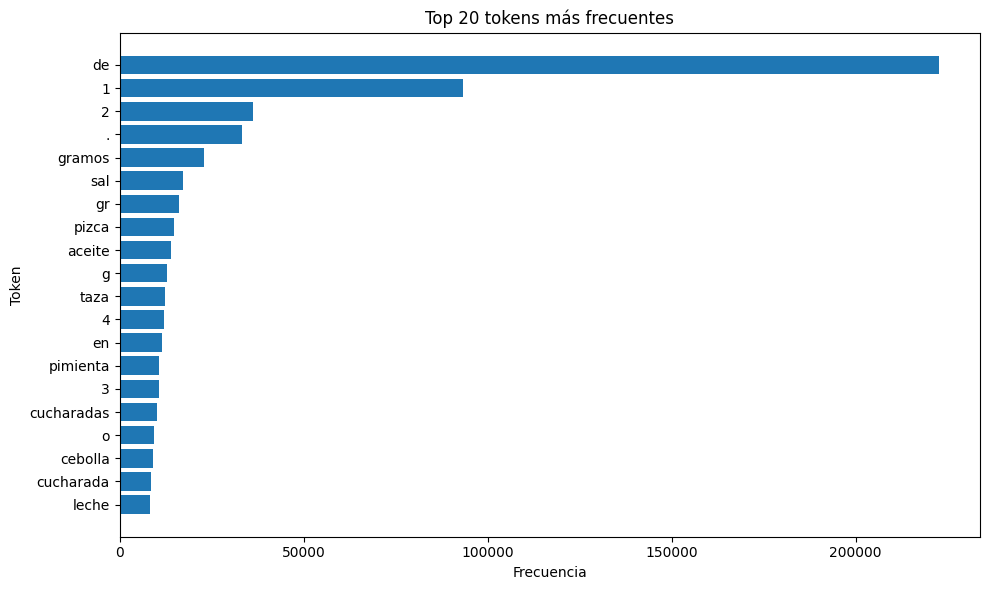

In [26]:
# ============================================================
# 15. Visualización de tokens frecuentes
# ============================================================

import matplotlib.pyplot as plt

top_tokens = tokens_frecuentes.head(20)

plt.figure(figsize=(10, 6))

plt.barh(
    top_tokens["token"][::-1],
    top_tokens["frecuencia"][::-1]
)

plt.title("Top 20 tokens más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Token")

plt.tight_layout()
plt.show()

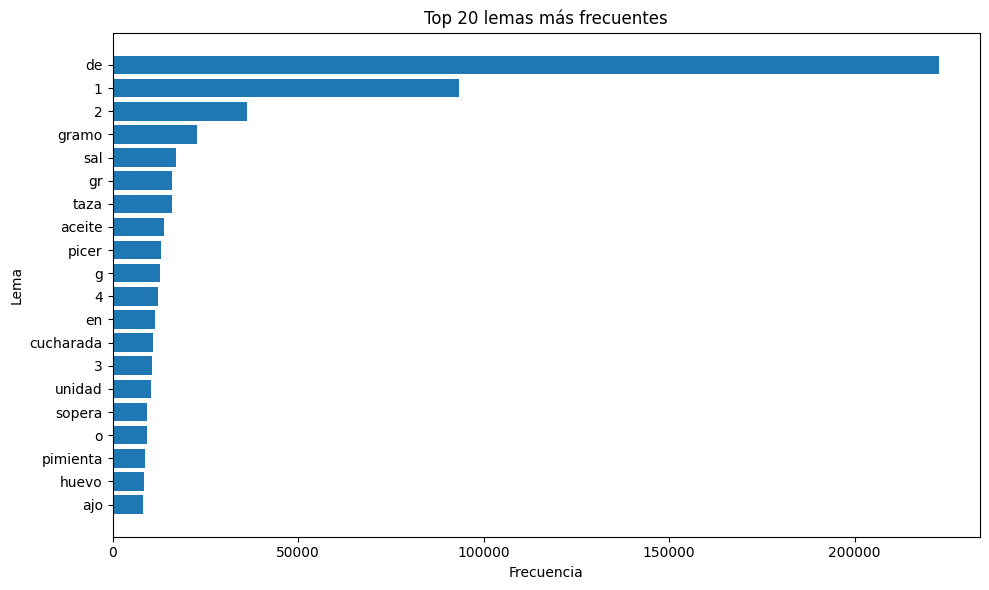

In [27]:
# ============================================================
# 16. Visualización de lemas frecuentes
# ============================================================

top_lemas = lemas_frecuentes.head(20)

plt.figure(figsize=(10, 6))

plt.barh(
    top_lemas["lema"][::-1],
    top_lemas["frecuencia"][::-1]
)

plt.title("Top 20 lemas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Lema")

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# 17. Validación manual de resultados NLP
# ============================================================

recetas_nlp[
    [
        "ingrediente_linea",
        "ingrediente_linea_limpia",
        "tokens_linea",
        "lemas_linea",
        "pos_linea"
    ]
].sample(15, random_state=42)

,ingrediente_linea,ingrediente_linea_limpia,tokens_linea,lemas_linea,pos_linea
16683,4 chuletas de ternera de 200 gr. cada una 30 g...,4 chuletas de ternera de 200 gr. cada una 30 g...,"[4, chuletas, de, ternera, de, 200, gr, ., cad...","[4, chuleta, de, ternera, de, 200, gr, cada, u...","[(4, NUM), (chuletas, NOUN), (de, ADP), (terne..."
4148,1 libra de lomo de res cortado en tajadas delg...,1 libra de lomo de res cortado en tajadas delg...,"[1, libra, de, lomo, de, res, cortado, en, taj...","[1, libra, de, lomo, de, r, cortado, en, tajad...","[(1, NUM), (libra, NOUN), (de, ADP), (lomo, NO..."
2527,1 aguacate pelado y en rodajas,1 aguacate pelado y en rodajas,"[1, aguacate, pelado, y, en, rodajas]","[1, aguacatar, pelado, y, en, rodaja]","[(1, NUM), (aguacate, VERB), (pelado, ADJ), (y..."
17470,200 gramos de carne picada de ternera 1 pizca ...,200 gramos de carne picada de ternera 1 pizca ...,"[200, gramos, de, carne, picada, de, ternera, ...","[200, gramo, de, carne, picado, de, ternera, 1...","[(200, NUM), (gramos, NOUN), (de, ADP), (carne..."
2388,4 cucharaditas de azúcar,4 cucharaditas de azucar,"[4, cucharaditas, de, azucar]","[4, cucharadita, de, azucar]","[(4, NUM), (cucharaditas, NOUN), (de, ADP), (a..."
10397,Agua c/n1 y 1/2 kg. de camarón mediano4 cdas. ...,agua c/n1 y 1/2 kg. de camaron mediano4 cdas. ...,"[agua, c, /, n1, y, 1/2, kg, ., de, camaron, m...","[agua, c, n1, y, 1/2, kg, de, camar, mediano4,...","[(agua, NOUN), (c, NOUN), (/, PUNCT), (n1, NUM..."
16384,Una cucharada de mantequilla Medio litro de na...,una cucharada de mantequilla medio litro de na...,"[una, cucharada, de, mantequilla, medio, litro...","[uno, cucharada, de, mantequilla, medio, litro...","[(una, DET), (cucharada, NOUN), (de, ADP), (ma..."
28965,1 kilo de auyama 8 tazas de agua 3 cucharadas ...,1 kilo de auyama 8 tazas de agua 3 cucharadas ...,"[1, kilo, de, auyama, 8, tazas, de, agua, 3, c...","[1, kilo, de, auyama, 8, taza, de, agua, 3, cu...","[(1, NUM), (kilo, NOUN), (de, ADP), (auyama, N..."
5623,500 gr. de arroz carnaroli 1/2 lt. de leche 6 ...,500 gr. de arroz carnaroli 1/2 lt. de leche 6 ...,"[500, gr, ., de, arroz, carnaroli, 1/2, lt, .,...","[500, gr, de, arroz, carnaroli, 1/2, lt, de, l...","[(500, NUM), (gr, PROPN), (., PUNCT), (de, ADP..."
1723,1 cucharada de aceite de oliva,1 cucharada de aceite de oliva,"[1, cucharada, de, aceite, de, oliva]","[1, cucharada, de, aceite, de, oliva]","[(1, NUM), (cucharada, NOUN), (de, ADP), (acei..."


In [29]:
# ============================================================
# 18. Guardado del dataset tokenizado y lematizado
# ============================================================

os.makedirs("data/interim", exist_ok=True)

output_path = "data/interim/recetas_tokenizadas_lematizadas.csv"

recetas_nlp.to_csv(output_path, index=False)

print("Dataset guardado correctamente")

print("Ruta:")
print(output_path)

print("Dimensiones:")
print(recetas_nlp.shape)

Dataset guardado correctamente
Ruta:
data/interim/recetas_tokenizadas_lematizadas.csv
Dimensiones:
(31587, 23)


In [30]:
print(""" CONCLUSIONES DE TOKENIZACIÓN Y LEMATIZACIÓN

Se aplicó spaCy como herramienta principal para el procesamiento lingüístico del texto culinario.

Se generaron representaciones tokenizadas de las líneas de ingredientes, permitiendo dividir el texto en unidades léxicas individuales.

Se generaron lemas para reducir variaciones morfológicas y facilitar procesos posteriores de matching y extracción de entidades.

Se obtuvieron etiquetas gramaticales (POS tags), útiles para identificar patrones lingüísticos relacionados con cantidades, unidades e ingredientes.

El análisis de tokens y lemas frecuentes permite identificar vocabulario recurrente dentro del dominio culinario colombiano.

El pipeline fue diseñado para generar dinámicamente las representaciones intermedias de los datos, evitando dependencia de archivos temporales pesados y garantizando reproducibilidad.

El dataset procesado servirá como entrada para la siguiente etapa: extracción de entidades culinarias mediante reglas, patrones lingüísticos y diccionarios especializados. """)



 CONCLUSIONES DE TOKENIZACIÓN Y LEMATIZACIÓN

Se aplicó spaCy como herramienta principal para el procesamiento lingüístico del texto culinario.

Se generaron representaciones tokenizadas de las líneas de ingredientes, permitiendo dividir el texto en unidades léxicas individuales.

Se generaron lemas para reducir variaciones morfológicas y facilitar procesos posteriores de matching y extracción de entidades.

Se obtuvieron etiquetas gramaticales (POS tags), útiles para identificar patrones lingüísticos relacionados con cantidades, unidades e ingredientes.

El análisis de tokens y lemas frecuentes permite identificar vocabulario recurrente dentro del dominio culinario colombiano.

El pipeline fue diseñado para generar dinámicamente las representaciones intermedias de los datos, evitando dependencia de archivos temporales pesados y garantizando reproducibilidad.

El dataset procesado servirá como entrada para la siguiente etapa: extracción de entidades culinarias mediante reglas, patrones